# 04_model_training

_This notebook will be filled in during its corresponding project phase._

In [4]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

# XGBoost is optional -- code still runs without it, just with 3 models
# instead of 4. This matches installing it via requirements.txt locally.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost not installed -- skipping it (pip install xgboost to include it)")

In [6]:
df = pd.read_csv("../data/processed/featured_data.csv")

X = df.drop(columns=["Exited"])
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 21)
y shape: (10000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train churn rate: 0.204
Test churn rate: 0.204


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, scale_pos_weight=neg / pos,
        random_state=42, eval_metric="logloss",
    )

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

In [10]:
results = []
fitted_models = {}

for name, model in models.items():
    # Logistic Regression uses the scaled features; tree models use raw ones
    uses_scaled = name == "Logistic Regression"
    X_tr = X_train_scaled if uses_scaled else X_train
    X_te = X_test_scaled if uses_scaled else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.862,0.800,0.431,0.561,0.864
3,XGBoost,0.838,0.613,0.559,0.585,0.837
0,Logistic Regression,0.728,0.402,0.686,0.507,0.792
1,Decision Tree,0.793,0.493,0.490,0.491,0.680


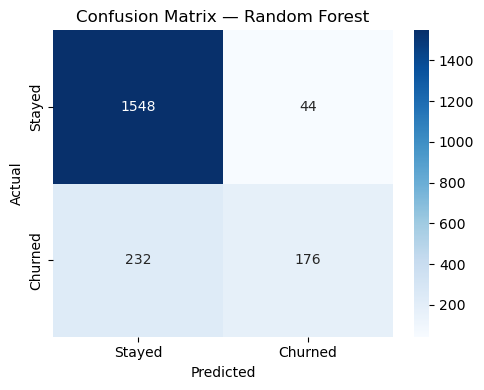

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1592
     Churned       0.80      0.43      0.56       408

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

uses_scaled = best_model_name == "Logistic Regression"
X_te = X_test_scaled if uses_scaled else X_test
y_pred_best = best_model.predict(X_te)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_best_model.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"]))

In [12]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated ROC-AUC:", round(grid_search.best_score_, 3))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.853


In [14]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest -- test set performance:")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_tuned), 3))
print("F1:", round(f1_score(y_test, y_pred_tuned), 3))

Tuned Random Forest -- test set performance:
ROC-AUC: 0.872
F1: 0.637


In [15]:
joblib.dump(tuned_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved model to models/churn_model.pkl")

Saved model to models/churn_model.pkl
